# Classical Models #
1. GBR
2. GPR
3. RFR


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, KFold
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn import svm

from sklearn.gaussian_process.kernels import RBF,WhiteKernel, ConstantKernel, Matern
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, root_mean_squared_error
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import csv
import os

myrcparams = {
    'axes.labelsize': 16,
    'axes.titlesize': 18,
    'legend.fontsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'figure.autolayout': True,
}
plt.rcParams.update(myrcparams)

In [2]:
n4_data = pd.read_excel('../../data/boron_coord_final.xlsx')

n4_data = n4_data.dropna(subset='%')

In [3]:
other = ['Cr2O3', 'HfO2', 'PbO', 'UO3', 'Y2O3','ZrO2','Fe2O3',
         'P2O5', 'TiO2', 'CoO','SrO','Cs2O','Bi2O3','BaO','SO3','La2O3']
oxEl = ['Al2O3','B2O3','CaO','K2O','Li2O','MgO','Na2O','SiO2',
 'ZnO','Rb2O']

n4_data['other'] = n4_data[other].sum(axis=1)
class_cols = oxEl + ['other']

X = n4_data[ class_cols ].fillna(0)
y = pd.DataFrame(n4_data['%'])

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_scaled = x_scaler.fit_transform(X_train) 
y_train_scaled = y_scaler.fit_transform(y_train)

X_test_scaled = x_scaler.transform(X_test)
y_test_scaled = y_scaler.transform(y_test)


# Hyperparameter Tuning using cross validataion



In [5]:
kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-2)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=100)

gbr = GradientBoostingRegressor(n_estimators=300,learning_rate=0.05, random_state=100, max_features=5)

rfr = RandomForestRegressor(n_estimators=1000, max_depth=12, random_state=100)

In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

In [7]:
filename = 'gpr_hyperparameter_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['kernel', 'r2', 'rmse'])
        writer.writeheader()

    kernels = [ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-2)]
    for kernel in kernels: 
        r2 = []
        rmse = []
        y_kscaler = StandardScaler()
        x_kscaler = StandardScaler()
        for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train)):
            X_ktrain = X_train.iloc[train_index]
            X_ktest = X_train.iloc[test_index]
            x_kpreprocess = x_kscaler.fit(X_ktrain)
            X_ktrain_scaled = x_kpreprocess.transform(X_ktrain)
            X_ktest_scaled = x_kpreprocess.transform(X_ktest)

            y_ktrain = y_train.to_numpy()[train_index]
            y_ktest = y_train.to_numpy()[test_index]
            y_kscaler.fit(y_ktrain.reshape(-1,1))
            y_ktrain_scaled = y_kscaler.transform(y_ktrain.reshape(-1, 1)).reshape( y_ktrain.shape)
            y_ktest_scaled = y_kscaler.transform(y_ktest.reshape(-1, 1)).reshape( y_ktest.shape)
            gpr.set_params(kernel=kernel)

            gpr.fit(X_ktrain_scaled, y_ktrain_scaled)

            y_pred_scaled = gpr.predict(X_ktest_scaled)
            y_pred = y_kscaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
            y_pred = np.maximum(y_pred, 0)
            
            r2_k = r2_score(y_ktest, y_pred)
            rmse_k = root_mean_squared_error(y_ktest, y_pred)

            r2.append(r2_k)
            rmse.append(rmse_k)

            dict = {'kernel': kernel,
            'r2': r2_k,
            'rmse': rmse_k}

            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

        dict = {'kernel': f'{kernel}_average',
                'r2': sum(r2)/len(r2),
                'rmse': sum(rmse)/len(rmse)}
        
        with open(filename, 'a', newline='') as file:
            writer = csv.DictWriter(file, fieldnames = dict.keys())
            writer.writerow(dict)

In [8]:
filename = 'gbr_hyperparameter_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['kernel', 'r2', 'rmse'])
        writer.writeheader()

    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['n_estimators', 'max_features', 'r2', 'rmse'])
        writer.writeheader()

    n_estimators = [100, 500, 1000]
    max_features = [5, 10, 50]
    for est in n_estimators: 
        for feature in max_features:
            r2 = []
            rmse = []
            x_kscaler = StandardScaler()
            y_kscaler =StandardScaler()
            for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train, y_train)):
                X_ktrain = X_train.iloc[train_index]
                X_ktest = X_train.iloc[test_index]
                x_kpreprocess = x_kscaler.fit(X_ktrain)
                X_ktrain_scaled = x_kpreprocess.transform(X_ktrain)
                X_ktest_scaled = x_kpreprocess.transform(X_ktest)

                y_ktrain = y_train.to_numpy()[train_index]
                y_ktest = y_train.to_numpy()[test_index]
                y_kscaler.fit(y_ktrain.reshape(-1,1))
                y_ktrain_scaled = y_kscaler.transform(y_ktrain.reshape(-1, 1)).reshape( y_ktrain.shape)
                y_ktest_scaled = y_kscaler.transform(y_ktest.reshape(-1, 1)).reshape( y_ktest.shape)
                gbr.set_params(n_estimators=est, max_features=feature)

                gbr.fit(X_ktrain_scaled, y_ktrain_scaled)

                y_pred_scaled = gbr.predict(X_ktest_scaled)
                y_pred = y_kscaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
                y_pred = np.maximum(y_pred, 0)
                
                r2_k = r2_score(y_ktest, y_pred)
                rmse_k = root_mean_squared_error(y_ktest, y_pred)

                r2.append(r2_k)
                rmse.append(rmse_k)

                dict = {'n_estimators': est,
                        'max_features': feature,
                        'r2': r2_k,
                        'rmse': rmse_k}

                with open(filename, 'a', newline='') as file:
                    writer = csv.DictWriter(file, fieldnames = dict.keys())
                    writer.writerow(dict)

            dict = {'n_estimators': f'{est}_avg',
                    'max_features':  f'{feature}_avg',
                    'r2': sum(r2)/len(r2),
                    'rmse': sum(rmse)/len(rmse)}
            
            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

In [9]:
filename = 'rfr_hyperparameter_tuning.csv'

if not os.path.exists(f'./{filename}'):
    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['kernel', 'r2', 'rmse'])
        writer.writeheader()

    with open(filename, 'w', newline='') as file:
        writer = csv.DictWriter(file, fieldnames = ['n_estimators', 'max_features', 'r2', 'rmse'])
        writer.writeheader()

    n_estimators = [100, 500, 1000]
    max_features = [5, 10, 50]
    for est in n_estimators: 
        for feature in max_features:
            r2 = []
            rmse = []
            x_kscaler = StandardScaler()
            y_kscaler = StandardScaler()
            for fold_idx, (train_index, test_index) in enumerate(kf.split(X_train, y_train)):
                X_ktrain = X_train.iloc[train_index]
                X_ktest = X_train.iloc[test_index]
                x_kpreprocess = x_kscaler.fit(X_ktrain)
                X_ktrain_scaled = x_kpreprocess.transform(X_ktrain)
                X_ktest_scaled = x_kpreprocess.transform(X_ktest)

                y_ktrain = y_train.to_numpy()[train_index]
                y_ktest = y_train.to_numpy()[test_index]
                y_kscaler.fit(y_ktrain.reshape(-1,1))
                y_ktrain_scaled = y_kscaler.transform(y_ktrain.reshape(-1, 1)).reshape( y_ktrain.shape)
                y_ktest_scaled = y_kscaler.transform(y_ktest.reshape(-1, 1)).reshape( y_ktest.shape)
                rfr.set_params(n_estimators=est, max_features=feature)

                rfr.fit(X_ktrain_scaled, y_ktrain_scaled)

                y_pred_scaled = rfr.predict(X_ktest_scaled)
                y_pred = y_kscaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).reshape(y_pred_scaled.shape)
                y_pred = np.maximum(y_pred, 0)
                r2_k = r2_score(y_ktest, y_pred)
                rmse_k = root_mean_squared_error(y_ktest, y_pred)

                r2.append(r2_k)
                rmse.append(rmse_k)

                dict = {'n_estimators': est,
                        'max_features': feature,
                        'r2': r2_k,
                        'rmse': rmse_k}

                with open(filename, 'a', newline='') as file:
                    writer = csv.DictWriter(file, fieldnames = dict.keys())
                    writer.writerow(dict)

            dict = {'n_estimators': f'{est}_avg',
                    'max_features':  f'{feature}_avg',
                    'r2': sum(r2)/len(r2),
                    'rmse': sum(rmse)/len(rmse)}
            
            with open(filename, 'a', newline='') as file:
                writer = csv.DictWriter(file, fieldnames = dict.keys())
                writer.writerow(dict)

# Select best hyperparameters

In [10]:
# Define filenames for hyperparameter tuning results
filenames_dict = {
    'gpr': 'gpr_hyperparameter_tuning.csv',  # Gaussian Process Regressor
    'rfr': 'rfr_hyperparameter_tuning.csv',  # Random Forest Regressor
    'gbr': 'gbr_hyperparameter_tuning.csv'  # Gradient Boosting Regressor
}

best_hyperparameters = {}  # Dictionary to store best hyperparameters for each model

# Iterate through each model and its corresponding CSV file
for model_name, filename in filenames_dict.items():
    print(f"\n{model_name.upper()}:")
    
    try:
        # Step 1: Read the CSV file
        df = pd.read_csv(filename)
        
        # Step 2: Filter rows where hyperparameters are NOT averages
        df_filtered = df[df[df.columns[0]].astype(str).str.contains('_avg')]
        
        # Step 3: Define the performance metric for selecting the best hyperparameters
        best_row = df_filtered.loc[df_filtered['r2'].idxmax()]  # Row with the highest R² value
        # Alternatively, minimize RMSE:
        # best_row = df_filtered.loc[df_filtered['rmse'].idxmin()] 
        
        # Step 4: Dynamically extract hyperparameter columns
        hyperparameters = {col: best_row[col].replace('_avg','') for col in df.columns if col not in ['r2', 'rmse']}
        
        # Save best hyperparameters for the model
        best_hyperparameters[model_name] = hyperparameters
        
        # Extract performance metrics
        best_r2 = best_row['r2']
        best_rmse = best_row['rmse']
        
        # Print the best hyperparameters and performance metrics
        print("Best Hyperparameters:")
        for param_name, param_value in hyperparameters.items():
            print(f"  {param_name}: {param_value}")
        
        print("Performance:")
        print(f"  R²: {best_r2}")
        print(f"  RMSE: {best_rmse}")
    
    except Exception as e:
        # Handle errors gracefully
        print(f"Error processing {model_name.upper()}: {str(e)}")


GPR:
Error processing GPR: attempt to get argmax of an empty sequence

RFR:
Best Hyperparameters:
  n_estimators: 500
  max_features: 5
Performance:
  R²: 0.8223112530674989
  RMSE: 9.026747655840936

GBR:
Best Hyperparameters:
  n_estimators: 1000
  max_features: 5
Performance:
  R²: 0.8457418861834093
  RMSE: 8.416145259852005


# Evaluate Test Data

In [11]:
# Now use the best hyperparameters to define the models dynamically
print("\nDefining models using best hyperparameters...")

kernel = ConstantKernel(1.0, (1e-3, 1e3)) * RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-2)
gpr = GaussianProcessRegressor(kernel=kernel, random_state=100)
print(f"GPR defined with kernel: {kernel}")

# Define Random Forest Regressor (RFR)
if 'rfr' in best_hyperparameters:
    rfr_params = best_hyperparameters['rfr']
    rfr = RandomForestRegressor(
        n_estimators=int(rfr_params['n_estimators']),
        max_features=int(rfr_params['max_features']),
        max_depth=12,
        random_state=100
    )
    print(f"RFR defined with: {rfr_params}")

# Define Gradient Boosting Regressor (GBR)
if 'gbr' in best_hyperparameters:
    gbr_params = best_hyperparameters['gbr']
    gbr = GradientBoostingRegressor(
        n_estimators=int(gbr_params['n_estimators']),
        max_features=int(gbr_params['max_features']),
        learning_rate=0.05,
        random_state=100
    )
    print(f"GBR defined with: {gbr_params}")


Defining models using best hyperparameters...
GPR defined with kernel: 1**2 * RBF(length_scale=1) + WhiteKernel(noise_level=0.01)
RFR defined with: {'n_estimators': '500', 'max_features': '5'}
GBR defined with: {'n_estimators': '1000', 'max_features': '5'}


### Gaussian Process Regressor

In [12]:
gpr.fit(X_train_scaled,y_train_scaled)
gpr_y_pred_scaled, gpr_sigma_scaled = gpr.predict(X_test_scaled, return_std = True)
gpr_y_pred = y_scaler.inverse_transform(gpr_y_pred_scaled.reshape(-1, 1)).reshape(gpr_y_pred_scaled.shape)
gpr_y_pred = np.maximum(gpr_y_pred, 0)
print(f'r2: {r2_score(y_test,gpr_y_pred):.2f},rmse {root_mean_squared_error(y_test,gpr_y_pred):.2f} ')

##csv
gpr_r2 =r2_score(y_test,gpr_y_pred)
gpr_rmse = root_mean_squared_error(y_test,gpr_y_pred)



r2: 0.88,rmse 7.59 


### Gradient Boost

In [13]:
gbr.fit(X_train_scaled, y_train_scaled)

gbr_y_pred_scaled = gbr.predict(X_test_scaled)
gbr_y_pred = y_scaler.inverse_transform(gbr_y_pred_scaled.reshape(-1, 1)).reshape(gbr_y_pred_scaled.shape)
gbr_y_pred = np.maximum(gbr_y_pred, 0)
print(f'r2: {r2_score(y_test,gbr_y_pred):.2f},rmse {root_mean_squared_error(y_test,gbr_y_pred):.2f} ')
gbr_r2 =r2_score(y_test,gbr_y_pred)
gbr_rmse = root_mean_squared_error(y_test,gbr_y_pred)


c:\Users\curr666\AppData\Local\miniconda3\envs\nepheline\lib\site-packages\sklearn\ensemble\_gb.py:672: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


r2: 0.86,rmse 8.08 


### Random Forest

In [14]:
rfr.fit(X_train_scaled, y_train_scaled)

rfr_y_pred_scaled = rfr.predict(X_test_scaled)
rfr_y_pred = y_scaler.inverse_transform(rfr_y_pred_scaled.reshape(-1, 1)).reshape(rfr_y_pred_scaled.shape)
rfr_y_pred = np.maximum(rfr_y_pred, 0)
print(f'r2: {r2_score(y_test,rfr_y_pred):.2f},rmse {root_mean_squared_error(y_test,rfr_y_pred):.2f} ')
rfr_r2 =r2_score(y_test,rfr_y_pred)
rfr_rmse = root_mean_squared_error(y_test,rfr_y_pred)


c:\Users\curr666\AppData\Local\miniconda3\envs\nepheline\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


r2: 0.85,rmse 8.36 


# Save model results

In [15]:
# Create prediction results for each model
# Dictionary to store all model predictions
model_results = {}

# Get predictions for all models
models = {
    'GPR': gpr,
    'GBR': gbr,
    'RFR': rfr
}

# Create predictions for all models
for model_name, model in models.items():
    # Training predictions
    train_preds_scaled = model.predict(X_train_scaled)
    train_preds = y_scaler.inverse_transform(train_preds_scaled.reshape(-1, 1)).reshape(train_preds_scaled.shape)
    train_preds = np.maximum(train_preds, 0)
    train_df = pd.DataFrame({
        'y_true': y_train['%'],
        'y_pred': train_preds,
        'is_train': 1
    }, index=y_train.index)
    
    # Test predictions
    test_preds_scaled = model.predict(X_test_scaled)
    test_preds =y_scaler.inverse_transform(test_preds_scaled.reshape(-1, 1)).reshape(test_preds_scaled.shape)
    test_preds = np.maximum(test_preds, 0)

    test_df = pd.DataFrame({
        'y_true': y_test['%'],
        'y_pred': test_preds,
        'is_train': 0
    }, index=y_test.index)

    # Combine train and test results
    model_results[model_name] = pd.concat([train_df, test_df])

# Join with Glass ID from the original dataset
for model_name, results in model_results.items():
    # Join with glass ID
    full_results = n4_data['Glass Name'].to_frame().join(results, how='left')
    
    # Rename column to match your original format
    full_results.rename(columns={'Glass Name': 'glass_name'}, inplace=True)
    
    # Store back in the dictionary
    model_results[model_name] = full_results

# # Save results to CSV files
for model_name, results_df in model_results.items():
    results_df.to_csv(f"../results/regression/{model_name}_with_cr_results.csv")

# Plot Results

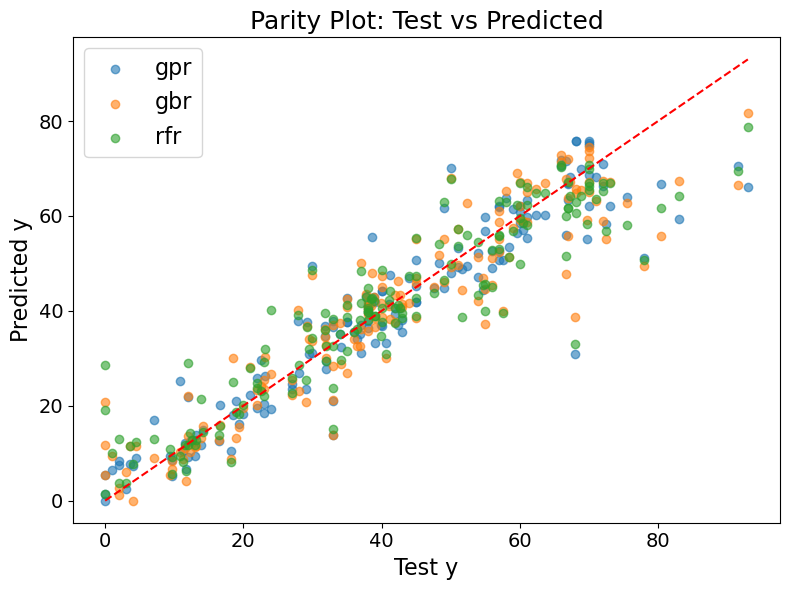

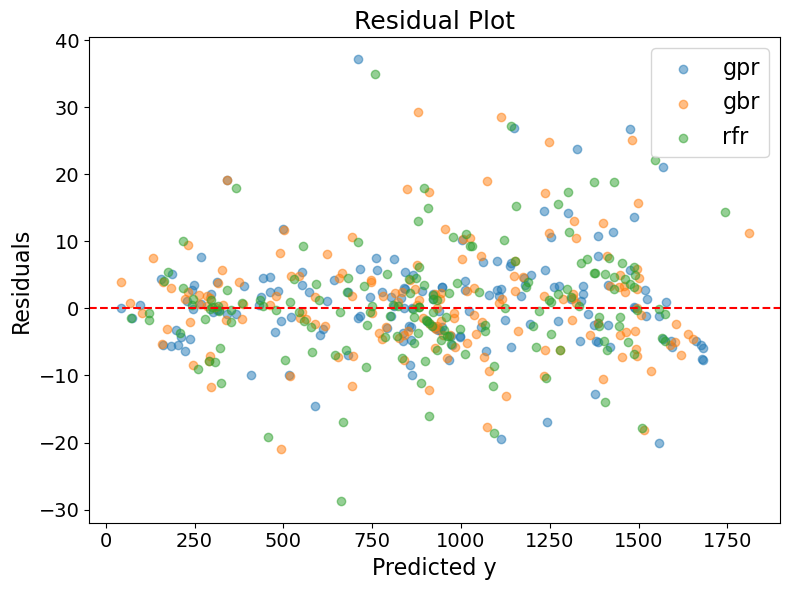

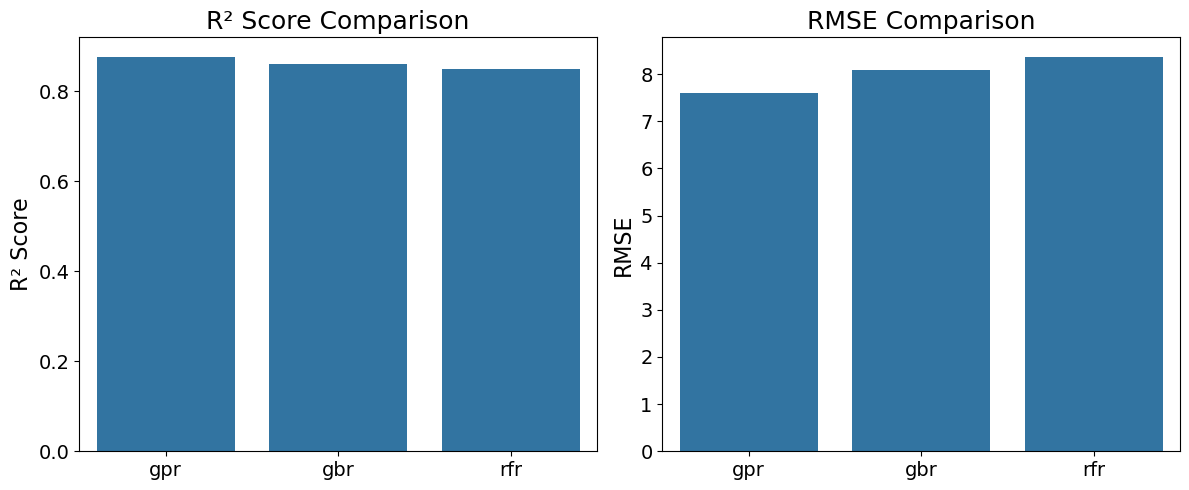

In [16]:
y_test = y_test.to_numpy().flatten()
models = ['gpr', 'gbr', 'rfr']
y_preds = [gpr_y_pred, gbr_y_pred, rfr_y_pred]
r2 = [gpr_r2, gbr_r2, rfr_r2]
rmse = [gpr_rmse, gbr_rmse, rfr_rmse]

plt.figure(figsize=(8,6))
for i, (model, y_pred) in enumerate(zip(models, y_preds)):
    plt.scatter(y_test, y_pred, alpha=0.6, label=model)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r--')  # Ideal line
plt.xlabel("Test y")
plt.ylabel("Predicted y")
plt.title("Parity Plot: Test vs Predicted")
plt.legend()
plt.show()

# 2. Residual Plot
plt.figure(figsize=(8, 6))
for model, y_pred in zip(models, y_preds):
    # print(y_test.to_numpy().flatten())
    # print(type(y_pred))
    residuals = y_test - y_pred
    plt.scatter(y_scaler.inverse_transform(y_pred.reshape(-1,1)), residuals, alpha=0.5, label=model)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted y")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend()
plt.show()

# 3. Bar Plot for R² and RMSE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(x=models, y=r2, ax=axes[0])
axes[0].set_title("R² Score Comparison")
axes[0].set_ylabel("R² Score")

sns.barplot(x=models, y=rmse, ax=axes[1])
axes[1].set_title("RMSE Comparison")
axes[1].set_ylabel("RMSE")

plt.show()